# Log surface estimation using random fields from laser scanner data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import math

import util

import scipy.linalg as la
import scipy.sparse.linalg as spla
import scipy.sparse as sp
import scipy.sparse as sp
import skfem as fem
from skfem.models.poisson import mass, laplace
from sksparse.cholmod import cholesky as spchol
from scipy.special import gammaln

## Data

* 3D point clouds of logs, measured in a real sawmill environment.
* Each log has a point cloud $\mathcal{P} = \left\{ \bm{p}_i \right\}_{i=1}^n = \left\{(x_i, y_i, z_i) \right\}_{i=1}^n$
* Physical units: $[x_i] = [y_i] = [z_i] = \text{mm}$
* Each point cloud is composed of layers in discrete steps along $z$-axis
* Strong presence outliers, projected from elements surrounding the log.

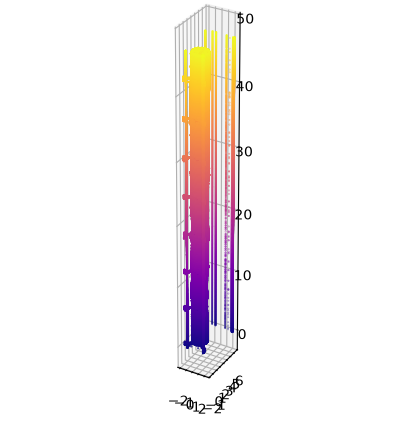

In [2]:
pointclouds = h5py.File("./pointclouds.h5", "r")
layers, points = util.load_pointcloud(pointclouds, "log001", scale=100, return_layers=True)

_, ax = plt.subplots(figsize=(5, 5), subplot_kw={"projection": "3d"})
ax.scatter(*points.T, s=0.1, c=layers, cmap="plasma")
ax.set_aspect("equal")
plt.show()

## Objective

* Model the surface of the log as a smooth manifold
* Ideal as a parametric model $\bm{p}: \mathbb{R}\times[0, 2\pi] \rightarrow \mathbb{R}^3$:
$$
\bm{p}(\ell, \theta) =
\begin{pmatrix} x(\ell)\\y(\ell)\\\ell \end{pmatrix} +
r(\ell, \theta)(\cos\theta e_1 + \theta\sin\theta e_2)
$$
* $r(\ell, 0) = r(\ell, 2\pi)$

## Approach

* $x'(z), y'(z) \sim \text{independent GPs}$
* $\log(r(z, \theta)) \sim \text{cylindrical GP}$
* $c'(z) = (x'(z), y'(z), 1)$
* $c(z) = p_0 + \int_0^z c'(u) \mathrm{d}u$
* $t(z) = \frac{c'(t)}{||c'(t)||}$
* $(e_1, e_2) = \text{parallel transport along } t$
* $p(z, \theta) = c(z) + r(z, \theta)(e_1 \cos\theta + e_2 \sin\theta)$

Subscripts refer to the input domain. We resort to covariances of the Matèrn class.

In [3]:
def parallel_transport(xy_prime):

    N = len(xy_prime)
    tangents = np.pad(xy_prime, ((0, 0), (0, 1)), constant_values=1.0)
    tangents /= np.linalg.norm(tangents, axis=1, keepdims=True)

    e1 = np.zeros((N, 3))
    e2 = np.zeros((N, 3))

    # Initial frame
    a = np.array([0.0, 0.0, 1.0])

    if abs(np.dot(a, tangents[0])) > 0.9:
        a = np.array([1.0, 0.0, 0.0])

    e1[0] = a - np.dot(a, tangents[0]) * tangents[0]
    e1[0] /= np.linalg.norm(e1[0])

    e2[0] = np.cross(tangents[0], e1[0])
    e2[0] /= np.linalg.norm(e2[0])

    for i in range(N - 1):

        t0 = tangents[i]
        t1 = tangents[i + 1]

        axis = np.cross(t0, t1)
        s = np.linalg.norm(axis)
        d = np.clip(np.dot(t0, t1), -1.0, 1.0)

        # Tangents essentially identical
        if s < 1e-12:
            R = np.eye(3)

        else:
            axis /= s
            # Rodrigues rotation
            K = np.array([
                [0,         -axis[2],  axis[1]],
                [axis[2],   0,        -axis[0]],
                [-axis[1],  axis[0],  0]
            ])
            theta = np.arctan2(s, d)
            R = (
                np.eye(3)
                + np.sin(theta) * K
                + (1 - np.cos(theta)) * (K @ K)
            )

        e1[i + 1] = R @ e1[i]
        e2[i + 1] = R @ e2[i]

    return e1, e2, tangents


def get_pith(xy_prime, p0=np.zeros(3), dz=1.0):
    xyz_diff = np.pad(xy_prime, ((0, 0), (0, 1)), constant_values=1.0)
    return np.r_[[p0], p0 + np.cumsum(xyz_diff[:-1], axis=0) * dz]

In [247]:
def sample_matern_spde(d, C, G, nu, kappa, sigma, n_samples=1):

    assert nu > 0, "nu must be positive"
    assert kappa > 0, "kappa must be positive"
    assert sigma > 0, "sigma must be positive"

    alpha_float = nu + d / 2
    alpha = round(alpha_float)
    assert np.isclose(alpha_float, alpha) and alpha >= 1, f"alpha = nu + d/2 must be an integer >= 1"

    n = C.shape[0]
    K = kappa**2 * C + G
    C_L = np.asarray(C.sum(axis=1)).ravel()
    solve_K = spla.factorized(K.tocsc())

    if alpha % 2 == 0:
        xi = np.sqrt(C_L)[:, None] * np.random.randn(n, n_samples)
        w = solve_K(xi)
        iters = alpha // 2 - 1
    else:
        z = np.random.randn(n, n_samples)
        U_K, _ = spchol(K.tocsc(), lower=False)
        w = spla.spsolve_triangular(U_K, z, lower=False)
        iters = (alpha - 1) // 2
    
    for _ in range(iters):
        w = solve_K(w * C_L[:, None])

    log_tau = (
        0.5 * (gammaln(nu) - gammaln(alpha_float))
        - np.log(sigma)
        - (d / 4) * np.log(4 * np.pi)
        - nu * np.log(kappa)
    )

    return w.T / np.exp(log_tau)


In [248]:
def sample_log(z_grid, t_grid, c_prime_params, r_params):
    n, m = map(len, (z_grid, t_grid))

    mesh_zp = fem.MeshLine(z_grid)
    basis_zp = fem.Basis(mesh_zp, fem.ElementLineP1())
    C_cp = fem.asm(mass, basis_zp)
    G_cp = fem.asm(laplace, basis_zp)

    mesh_r = fem.MeshTri1DG().init_tensor(z_grid, t_grid, periodic=[1])
    basis_r = fem.Basis(mesh_r, fem.ElementTriP1())
    C_r = fem.asm(mass, basis_r)
    G_r = fem.asm(laplace, basis_r)

    xy_prime = sample_matern_spde(1, C_cp, G_cp, *c_prime_params, 2).T
    r = np.exp(sample_matern_spde(2, C_r, G_r, *r_params, 1).reshape((n, m-1)))
    r = np.c_[r[:, -1], r]

    c = get_pith(xy_prime, dz=z_grid[1]-z_grid[0])
    e1, e2, _ = parallel_transport(xy_prime)

    _, tt = np.meshgrid(z_grid, t_grid, indexing='ij')
    
    ez = (
        np.expand_dims(np.cos(tt), -1) * np.expand_dims(e1, 1) +
        np.expand_dims(np.sin(tt), -1) * np.expand_dims(e2, 1)
    )
    
    return c, r, ez

Transforming over 1000 vertices to C_CONTIGUOUS.


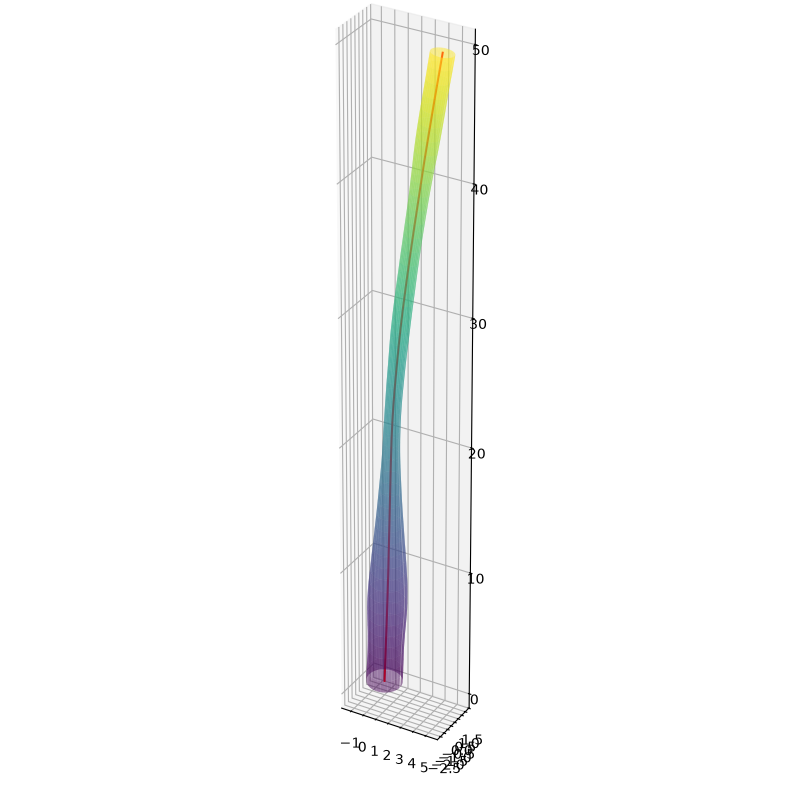

In [324]:
z_max = 50
dz = 0.1
dt = 0.1

c, r, ez = sample_log(
    np.arange(0, z_max, dz),
    np.arange(0, 2*np.pi, dt),
    (1.5, 0.1, 0.05),
    (2.0, 0.2, 0.2)
)

pp = np.expand_dims(c, 1) + np.expand_dims(r, -1) * ez
xx = pp[..., 0]
yy = pp[..., 1]
zz = pp[..., 2]

_, ax = plt.subplots(figsize=(10, 10), subplot_kw={"projection": "3d"})
ax.plot(*c.T, 'r')
ax.plot_surface(xx, yy, zz, cmap="viridis", alpha=0.5)
ax.set_aspect("equal")

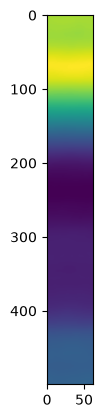

In [325]:
plt.imshow(r)

In [42]:
x = np.linspace(0, 40, 1000 * 360)
mesh = fem.MeshLine(x)
basis = fem.Basis(mesh, fem.ElementLineP1())

C = fem.asm(mass, basis)
G = fem.asm(laplace, basis)

# np.random.seed(24)
samples = sample_matern_spde(1, C, G, 2.5, 0.2, 1.0, 1)
# _ = plt.plot(x, samples.T)

print(f"{C.shape = }")
print(f"{G.shape = }")
print(f"{C.nnz = }")
print(f"{G.nnz = }")

C.shape = (360000, 360000)
G.shape = (360000, 360000)
C.nnz = 1079998
G.nnz = 1079998


Transforming over 1000 vertices to C_CONTIGUOUS.


C.shape = (17800, 17800)
G.shape = (17800, 17800)
C.nnz = 124244
G.nnz = 88822


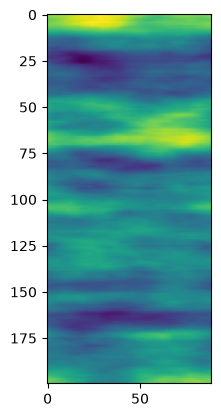

In [267]:
z = np.linspace(0, 40, 200)
theta = np.linspace(0, 2*np.pi, 90)
mesh = fem.MeshTri1DG().init_tensor(z, theta, periodic=[1])
basis = fem.Basis(mesh, fem.ElementTriP1())

C = fem.asm(mass, basis)
G = fem.asm(laplace, basis)

# np.random.seed(24)
sample = sample_matern_spde(2, C, G, 2, 1, 1.0, 1)

print(f"{C.shape = }")
print(f"{G.shape = }")
print(f"{C.nnz = }")
print(f"{G.nnz = }")

plt.imshow(sample.reshape((200, 89)))

In [44]:
import time

x = np.linspace(0, 40, 1000 * 360)
mesh = fem.MeshLine(x)
basis = fem.Basis(mesh, fem.ElementLineP1())

C = fem.asm(mass, basis)
G = fem.asm(laplace, basis)
K = 0.2**2 * C + G

t0 = time.perf_counter()
L, _ = spchol(K.tocsc())
t1 = time.perf_counter()

print(f"factorization: {t1 - t0:.3f} s")
print(f"K.nnz: {K.nnz:,}")
print(f"L.nnz: {L.nnz:,}")

factorization: 0.027 s
K.nnz: 1,079,998
L.nnz: 719,999


In [47]:
import time

z = np.linspace(0, 40, 1000)
theta = np.linspace(0, 2*np.pi, 360)
mesh = fem.MeshTri1DG().init_tensor(z, theta, periodic=[0])
basis = fem.Basis(mesh, fem.ElementTriP1())

C = fem.asm(mass, basis)
G = fem.asm(laplace, basis)

C = fem.asm(mass, basis)
G = fem.asm(laplace, basis)
K = 0.2**2 * C + G

t0 = time.perf_counter()
L, _ = spchol(K.tocsc())
t1 = time.perf_counter()

print(f"factorization: {t1 - t0:.3f} s")
print(f"K.nnz: {K.nnz:,}")
print(f"L.nnz: {L.nnz:,}")
print(f"{(1000 * 365)**2}")

Transforming over 1000 vertices to C_CONTIGUOUS.


factorization: 0.387 s
K.nnz: 2,513,484
L.nnz: 22,234,014
133225000000


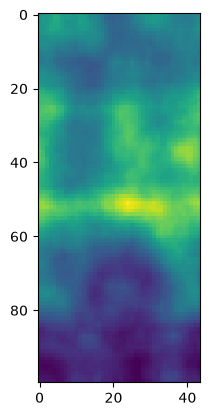

In [90]:
dof_z = basis_r.doflocs[0]
dof_theta = basis_r.doflocs[1]

z_unique = np.unique(dof_z)
theta_unique = np.unique(dof_theta)

iz = np.searchsorted(z_unique, dof_z)
itheta = np.searchsorted(theta_unique, dof_theta)

img = np.empty((len(z_unique), len(theta_unique)))
img[iz, itheta] = r[:, 1:].ravel()


plt.imshow(np.exp(img))

In [511]:
2 * np.pi

6.283185307179586

In [512]:
print(basis.doflocs.shape)
print(len(np.unique(basis.doflocs[0])))
print(len(np.unique(basis.doflocs[1])))
print(basis.doflocs[:, -20:])

(2, 359000)
1000
359
[[40.         40.         40.         40.         40.         40.
  40.         40.         40.         40.         40.         40.
  40.         40.         40.         40.         40.         40.
  40.         40.        ]
 [ 5.95064904  5.96815095  5.98565286  6.00315476  6.02065667  6.03815858
   6.05566049  6.0731624   6.09066431  6.10816622  6.12566813  6.14317004
   6.16067194  6.17817385  6.19567576  6.21317767  6.23067958  6.24818149
   6.2656834   6.28318531]]
